In [1]:
import pyodbc

print(pyodbc.drivers())

['SQL Server', 'Microsoft Access Driver (*.mdb, *.accdb)', 'Microsoft Excel Driver (*.xls, *.xlsx, *.xlsm, *.xlsb)', 'Microsoft Access Text Driver (*.txt, *.csv)', 'ODBC Driver 18 for SQL Server', 'ODBC Driver 17 for SQL Server']


In [77]:
import pyodbc

conexion = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=JasawePC2023\\SQLEXPRESS;'
    'DATABASE=Análisis_Datos_Clientes_Guia2;'
    'Trusted_Connection=yes;'
)

print("Conexión exitosa")

Conexión exitosa


# IMPORTAMOS LIBRERIAS NECESARIAS 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier


In [79]:
import pandas as pd

query = "SELECT * FROM dbo.Analisis_Datos_Clientes_Guia2"

df = pd.read_sql(query, conexion)

df.head()


C:\Users\HP\AppData\Local\Temp\ipykernel_24488\1475026629.py:5: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono
0,C2000,18,1842000,2,1,10,0,36,0,73.0,2,Bogotá,Tienda física,Rural,Básico,Alta,B,False
1,C2001,33,2326000,2,4,7,0,38,5,92.0,1,Barranquilla,Web,Urbana,Básico,Media,A,False
2,C2002,48,5048000,8,9,16,0,6,8,80.0,0,Medellín,Referido,Urbana,Medio,Alta,A,False
3,C2003,53,3641000,4,5,7,1,29,4,57.0,1,Cali,Tienda física,Urbana,Medio,Baja,D,False
4,C2004,48,2144000,4,4,34,0,42,2,83.0,4,Cali,Redes sociales,Rural,Básico,Alta,B,False


 # EXPLORACIÓN INICIAL

In [80]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               360 non-null    str    
 1   Edad                     360 non-null    int64  
 2   IngresoMensual           360 non-null    int64  
 3   CantidadCompras          360 non-null    int64  
 4   ComprasUltimos12M        360 non-null    int64  
 5   AntiguedadMeses          360 non-null    int64  
 6   QuejasUltimos6M          360 non-null    int64  
 7   DiasDesdeUltimaCompra    360 non-null    int64  
 8   VisitasWebUltimoMes      360 non-null    int64  
 9   TiempoPromedioSesionMin  360 non-null    float64
 10  CuponesUsados            360 non-null    int64  
 11  Ciudad                   360 non-null    str    
 12  CanalPreferido           360 non-null    str    
 13  ZonaResidencia           360 non-null    str    
 14  Segmento                 360 non-null

In [81]:
df.describe()

,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados
count,360.000000,3.600000e+02,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000,360.000000
mean,36.119444,3.318497e+06,5.436111,5.394444,26.191667,0.836111,40.441667,5.227778,76.291667,2.152778
std,9.976555,1.627261e+06,3.586003,3.787529,15.002672,1.098658,26.046817,3.040727,26.471111,1.628949
min,18.000000,9.000000e+05,0.000000,0.000000,3.000000,0.000000,1.000000,0.000000,10.000000,0.000000
25%,28.000000,2.182750e+06,3.000000,3.000000,15.000000,0.000000,21.000000,3.000000,59.000000,1.000000
50%,36.000000,3.011000e+06,5.000000,5.000000,23.000000,0.500000,36.000000,5.000000,77.000000,2.000000
75%,42.250000,4.026250e+06,8.000000,8.000000,33.250000,1.000000,54.250000,7.000000,93.000000,3.000000
max,68.000000,9.800000e+06,22.000000,22.000000,83.000000,5.000000,151.000000,16.000000,153.000000,8.000000



# DESCRIPCIÓN DEL NEGOCIO
El conjunto de datos analizado corresponde a una base de clientes compuesta por 360 registros y 18 variables, orientada al análisis del comportamiento comercial y la predicción de abandono de clientes en un entorno de negocio probablemente asociado al comercio electrónico, retail o servicios digitales.
Desde la perspectiva del negocio, la variable objetivo denominada “Abandono” se encuentra en formato booleano, permitiendo identificar si un cliente permanece activo o abandona la empresa, lo cual sugiere un caso de uso enfocado en modelos de clasificación supervisada para estrategias de retención y fidelización. El dataset integra variables demográficas como Edad, Ciudad y ZonaResidencia, las cuales permiten segmentar clientes según características poblacionales y territoriales; variables económicas como IngresoMensual, útiles para identificar capacidad adquisitiva y valor potencial del cliente; y variables de comportamiento transaccional como CantidadCompras, ComprasUltimos12M, AntiguedadMeses, DiasDesdeUltimaCompra y CuponesUsados, que reflejan frecuencia de compra, permanencia y nivel de interacción comercial con la empresa. Asimismo, incorpora variables digitales y de experiencia de usuario como VisitasWebUltimoMes y TiempoPromedioSesionMin, fundamentales para comprender el nivel de actividad e interés del cliente en plataformas digitales. Las variables QuejasUltimos6M y Satisfaccion aportan una visión relacionada con la experiencia y percepción del servicio, factores clave en el análisis de churn o abandono. También se incluyen variables estratégicas de mercadeo como CanalPreferido, Segmento y CodigoCampania, las cuales permiten evaluar efectividad de campañas, canales de atención y perfiles comerciales. En términos técnicos, el dataset contiene 9 variables numéricas enteras (int64), asociadas principalmente a métricas operacionales y comerciales; 1 variable numérica continua (float64), correspondiente al tiempo promedio de sesión; 7 variables categóricas tipo texto (str), relacionadas con segmentación y caracterización del cliente; y 1 variable booleana como variable objetivo.
# OBJETIVO DEL ANALISIS
Segmentación de clientes, identificación de patrones de comportamiento, análisis de satisfacción y construcción de modelos predictivos orientados a disminuir la tasa de abandono y fortalecer la toma de decisiones estratégicas del negocio.

# VERIFICAR EL NOMBRE DE LAS COLUMNAS 

In [82]:
df.columns

Index(['ID_Cliente', 'Edad', 'IngresoMensual', 'CantidadCompras',
       'ComprasUltimos12M', 'AntiguedadMeses', 'QuejasUltimos6M',
       'DiasDesdeUltimaCompra', 'VisitasWebUltimoMes',
       'TiempoPromedioSesionMin', 'CuponesUsados', 'Ciudad', 'CanalPreferido',
       'ZonaResidencia', 'Segmento', 'Satisfaccion', 'CodigoCampania',
       'Abandono'],
      dtype='str')

# PREPARAR LA VARIABLE OBJETIVO
#la variable objetivo (abandono), está en formato o tipo buleano, verdadero o falso, por tal motivo para poder realizar el entrenamiento es necesario cambiar al tipo de datos correctos para que los resultados sean los esperados 

In [83]:
df["Abandono"] = df["Abandono"].astype(int)

In [84]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID_Cliente               360 non-null    str    
 1   Edad                     360 non-null    int64  
 2   IngresoMensual           360 non-null    int64  
 3   CantidadCompras          360 non-null    int64  
 4   ComprasUltimos12M        360 non-null    int64  
 5   AntiguedadMeses          360 non-null    int64  
 6   QuejasUltimos6M          360 non-null    int64  
 7   DiasDesdeUltimaCompra    360 non-null    int64  
 8   VisitasWebUltimoMes      360 non-null    int64  
 9   TiempoPromedioSesionMin  360 non-null    float64
 10  CuponesUsados            360 non-null    int64  
 11  Ciudad                   360 non-null    str    
 12  CanalPreferido           360 non-null    str    
 13  ZonaResidencia           360 non-null    str    
 14  Segmento                 360 non-null

# GRAFICAMOS LA VARIABLE OBJETIVO
#Graficamos la variable objetivo para identificar si las clases estan balanceadas

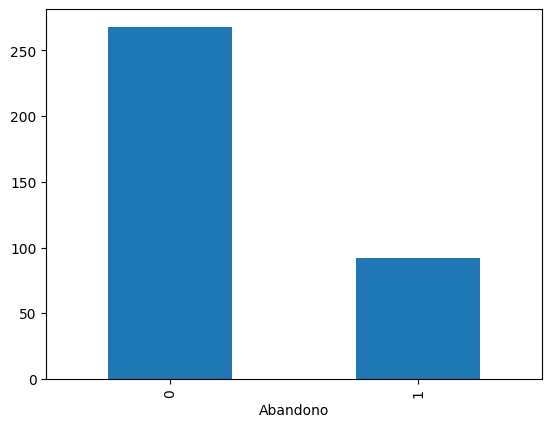

Abandono
0    74.444444
1    25.555556
Name: proportion, dtype: float64

In [85]:
df["Abandono"].value_counts().plot(kind="bar")
plt.show()
df["Abandono"].value_counts(normalize=True) * 100


# Analisis
la Variable objetivo "Abandono" presenta un desvalance moderado, donde la clase 0 representa el 74.44% de los registros y la clase  1 es el 25.56%. Aunque existe predominio de la clase mayoritaria, el nivel de desbalance no es severo y permite entrenar modelos supervisados aplicando particion estratificada.

# GRAFICAMOS LA VARIABLE EDAD
graficamos edad para analizar la distribución de edades, concentración de clientes, posibles outliers

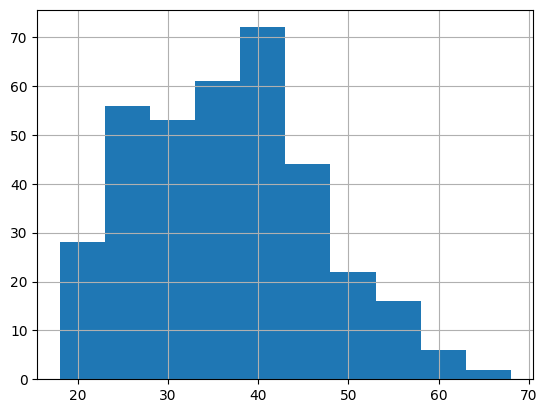

count    360.000000
mean      36.119444
std        9.976555
min       18.000000
25%       28.000000
50%       36.000000
75%       42.250000
max       68.000000
Name: Edad, dtype: float64

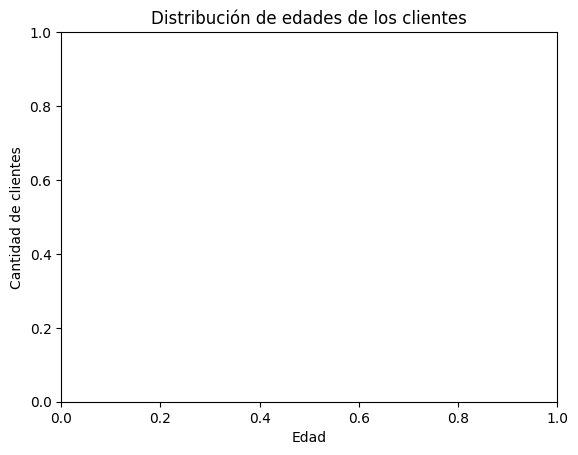

In [86]:
df["Edad"].hist()
plt.show()
plt.xlabel("Edad")
plt.ylabel("Cantidad de clientes")
plt.title("Distribución de edades de los clientes")
df["Edad"].describe()

# Análisis
La variable Edad presenta una distribución concentrada principalmente entre los 30 y 45 años, con un pico cercano a los 40 años. Se observa una ligera asimetría positiva debido a la presencia de algunos clientes de mayor edad, aunque no se evidencian valores atípicos extremos.

# GRAFICAMOS LA VARIABLE Ciudad

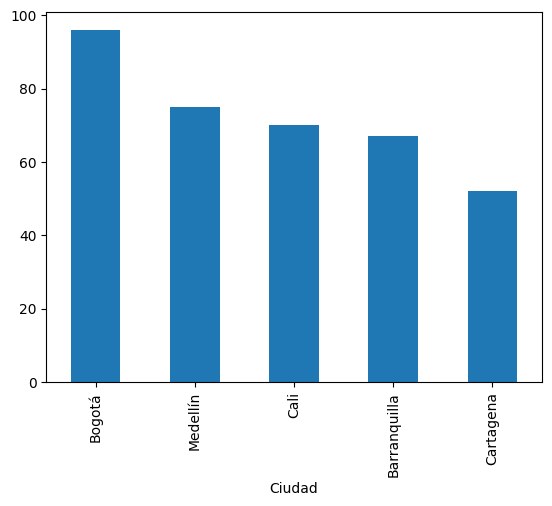

count        360
unique         5
top       Bogotá
freq          96
Name: Ciudad, dtype: object

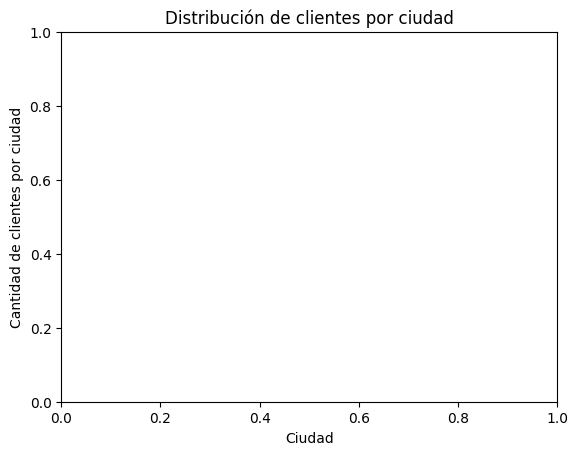

In [87]:
df["Ciudad"].value_counts().plot(kind="bar")
plt.show()

plt.xlabel("Ciudad")
plt.ylabel("Cantidad de clientes por ciudad")
plt.title("Distribución de clientes por ciudad")
df["Ciudad"].describe()


# GRAFICAMOS LA VARIABLE CantidadCompras

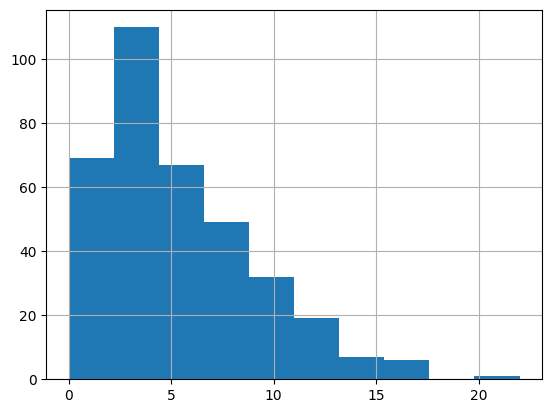

In [88]:
df["CantidadCompras"].hist()
plt.show()

# GRAFICAMOS LA VARIABLE INGRESO MENSUAL


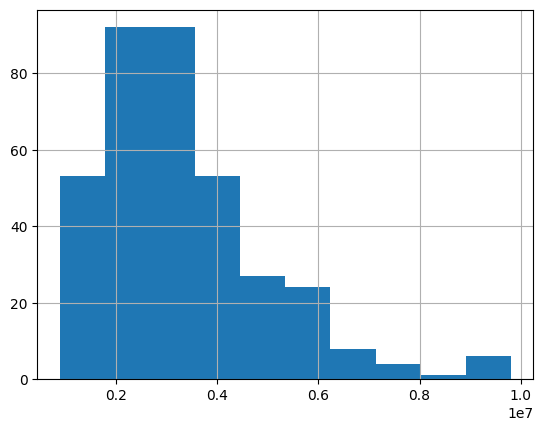

In [89]:
df["IngresoMensual"].hist()
plt.show()



# RELACION DE VARIABLES CON EL ABANDONO
#Esta relacion se hace con el objetivo de entender que variables influyen más con respecto a la variable objetivo.


# SATISFACCIÓN VS ABANDONO
Esta gráfica me permite analizar si clientes insatisfechos abandonan más


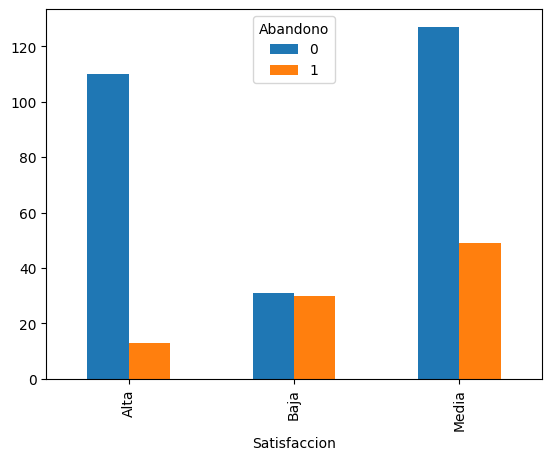

In [90]:
pd.crosstab(df["Satisfaccion"], df["Abandono"]).plot(kind="bar")

plt.show()

# CIUDAD VS ABANDONO
Esta comparación me indica cuantos clientes y de que ciudades abandonan el servicio


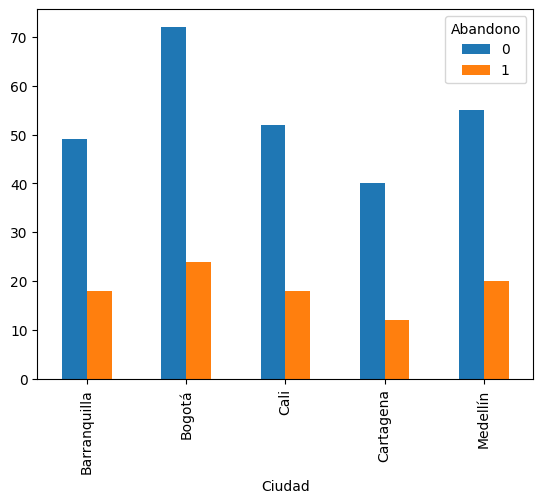

In [91]:
pd.crosstab(df["Ciudad"], df["Abandono"]).plot(kind="bar")

plt.show()

# SEGMENTO VS ABANDONO
Esta gráfica me indica que segmento del cliente se vió más afectado por el abandono 

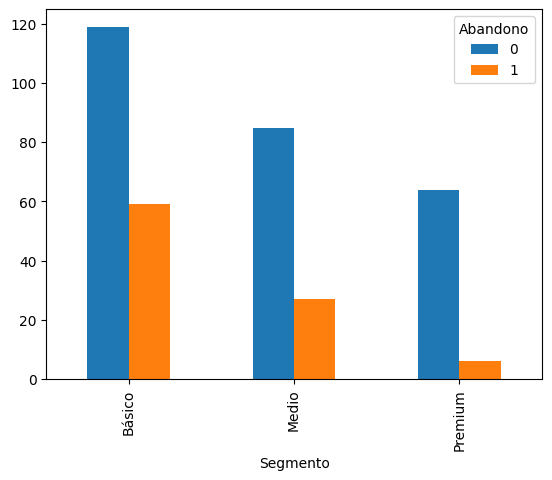

In [92]:
pd.crosstab(df["Segmento"], df["Abandono"]).plot(kind="bar")

plt.show()

# INGRESO VS ABANDONO
Esta gráfica me indica si quienes abandonan tienen ingresos distintos.

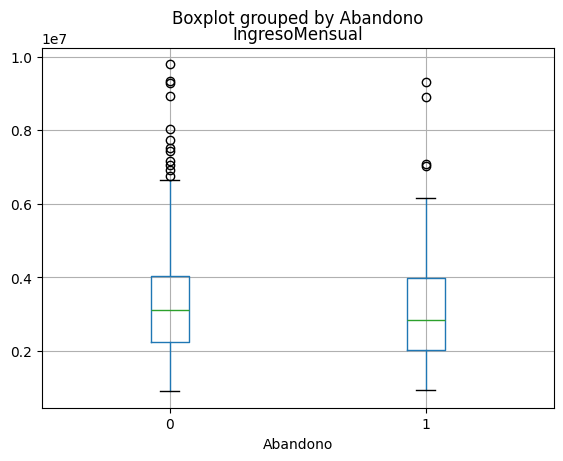

In [93]:
df.boxplot(column="IngresoMensual", by="Abandono")

plt.show()

# ANALISIS 
El boxplot de IngresoMensual agrupado por la variable Abandono muestra distribuciones similares entre los clientes que abandonan y los que permanecen. Las medianas presentan valores cercanos y se observan múltiples valores atípicos en ambos grupos, correspondientes a clientes con ingresos significativamente altos.


# IDENTIFICAMOS LOS TIPOS DE VARIABLES

# VARIABLES NUMÉRICAS
Edad,Ingreso Mensual, CantidadCompras,ComprasUltimos12M,AntiguedadMeses, QuejasUltimos6M, DiasDesdeUltimaCompra, VisitasWebUltimoMes,TiempoPromedioSesionMin,TiempoPromedioSesionMin
# VARIABLES CATEGÓRICA
Ciudad, CanalPreferido, ZonaResidencia, Segmento, Satisfacción, CodigoCampania
# VARIABLE OBJETIVO
Abandono

In [101]:
columnas_numericas = ["Edad", "IngresoMensual", "CantidadCompras", "ComprasUltimos12M", "AntiguedadMeses","CuponesUsados","QuejasUltimos6M","DiasDesdeUltimaCompra","VisitasWebUltimoMes","TiempoPromedioSesionMin","TiempoPromedioSesionMin"]
columnas_categoricas = ["Ciudad", "CanalPreferido", "ZonaResidencia","Segmento", "Satisfaccion","CodigoCampania"]
variable_objetivo = "Abandono"

print("Columnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)
print("Variable objetivo:", variable_objetivo)

Columnas numéricas: ['Edad', 'IngresoMensual', 'CantidadCompras', 'ComprasUltimos12M', 'AntiguedadMeses', 'CuponesUsados', 'QuejasUltimos6M', 'DiasDesdeUltimaCompra', 'VisitasWebUltimoMes', 'TiempoPromedioSesionMin', 'TiempoPromedioSesionMin']
Columnas categóricas: ['Ciudad', 'CanalPreferido', 'ZonaResidencia', 'Segmento', 'Satisfaccion', 'CodigoCampania']
Variable objetivo: Abandono


# SEPARAMOS VAFRIABLES PREDICTORAS DE VARIABLE OBJETIVO

In [106]:
X = df[[
    "Edad",
    "IngresoMensual",
    "CantidadCompras",
    "ComprasUltimos12M",
    "AntiguedadMeses",
    "QuejasUltimos6M",
    "DiasDesdeUltimaCompra",
    "VisitasWebUltimoMes",
    "TiempoPromedioSesionMin",
    "CuponesUsados",
    "Ciudad",
    "CanalPreferido",
    "ZonaResidencia",
    "Segmento",
    "Satisfaccion",
    "CodigoCampania"
]]

y = df["Abandono"]

print("Variables predictoras X:")
print(X.head())

print("Variable objetivo y:")
display(y)


Variables predictoras X:
   Edad  IngresoMensual  CantidadCompras  ...  Segmento  Satisfaccion  CodigoCampania
0    18         1842000                2  ...    Básico          Alta               B
1    33         2326000                2  ...    Básico         Media               A
2    48         5048000                8  ...     Medio          Alta               A
3    53         3641000                4  ...     Medio          Baja               D
4    48         2144000                4  ...    Básico          Alta               B

[5 rows x 16 columns]
Variable objetivo y:


0      0
1      0
2      0
3      0
4      0
      ..
355    0
356    0
357    0
358    0
359    0
Name: Abandono, Length: 360, dtype: int64

# Aplicamos codificación y escalamiento


In [108]:
X_procesado = preprocesador.fit_transform(X)

X_procesado




array([[-1.81873026, -0.90861411, -0.95953449, ...,  0.        ,
         0.        ,  0.        ],
       [-0.31311269, -0.61076782, -0.95953449, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.19250488,  1.06430992,  0.71596632, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.21273819,  0.51354042, -1.23878463, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.59025785,  1.3424639 , -0.68028436, ...,  0.        ,
         0.        ,  0.        ],
       [-1.81873026, -1.05507572, -0.40103422, ...,  0.        ,
         0.        ,  0.        ]], shape=(360, 35))

# OBTENEMOS NOMBRES DE LAS COLUMNAS NUEVAS

In [109]:
nombres_columnas = preprocesador.get_feature_names_out()

nombres_columnas

array(['numericas__Edad', 'numericas__IngresoMensual',
       'numericas__CantidadCompras', 'numericas__ComprasUltimos12M',
       'numericas__AntiguedadMeses', 'numericas__CuponesUsados',
       'numericas__QuejasUltimos6M', 'numericas__DiasDesdeUltimaCompra',
       'numericas__VisitasWebUltimoMes',
       'numericas__TiempoPromedioSesionMin',
       'numericas__TiempoPromedioSesionMin',
       'categoricas__Ciudad_Barranquilla', 'categoricas__Ciudad_Bogotá',
       'categoricas__Ciudad_Cali', 'categoricas__Ciudad_Cartagena',
       'categoricas__Ciudad_Medellín',
       'categoricas__CanalPreferido_Redes sociales',
       'categoricas__CanalPreferido_Referido',
       'categoricas__CanalPreferido_Tienda física',
       'categoricas__CanalPreferido_Web',
       'categoricas__ZonaResidencia_Periurbana',
       'categoricas__ZonaResidencia_Rural',
       'categoricas__ZonaResidencia_Urbana',
       'categoricas__Segmento_Básico', 'categoricas__Segmento_Medio',
       'categoricas__Segm

# CREAR EL DATASET FINAL PARA ENTRENAMIENTO
Convertimos el resultado en un DAtaFrame para verlo mejor, luego agregamos la columna Abandono.

In [110]:
df_final = pd.DataFrame(
    X_procesado,
    columns=nombres_columnas
)

df_final["Abandono"] = y.values

df_final

,numericas__Edad,numericas__IngresoMensual,numericas__CantidadCompras,numericas__ComprasUltimos12M,numericas__AntiguedadMeses,numericas__CuponesUsados,numericas__QuejasUltimos6M,numericas__DiasDesdeUltimaCompra,numericas__VisitasWebUltimoMes,numericas__TiempoPromedioSesionMin,numericas__TiempoPromedioSesionMin,categoricas__Ciudad_Barranquilla,categoricas__Ciudad_Bogotá,categoricas__Ciudad_Cali,categoricas__Ciudad_Cartagena,categoricas__Ciudad_Medellín,categoricas__CanalPreferido_Redes sociales,categoricas__CanalPreferido_Referido,categoricas__CanalPreferido_Tienda física,categoricas__CanalPreferido_Web,categoricas__ZonaResidencia_Periurbana,categoricas__ZonaResidencia_Rural,categoricas__ZonaResidencia_Urbana,categoricas__Segmento_Básico,categoricas__Segmento_Medio,categoricas__Segmento_Premium,categoricas__Satisfaccion_Alta,categoricas__Satisfaccion_Baja,categoricas__Satisfaccion_Media,categoricas__CodigoCampania_A,categoricas__CodigoCampania_B,categoricas__CodigoCampania_C,categoricas__CodigoCampania_D,categoricas__CodigoCampania_E,categoricas__CodigoCampania_F,Abandono
0,-1.818730,-0.908614,-0.959534,-1.161855,-1.080754,-0.093920,-0.762089,-0.170764,-1.721645,-0.124522,-0.124522,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,-0.313113,-0.610768,-0.959534,-0.368680,-1.280997,-0.708667,-0.762089,-0.093872,-0.075013,0.594240,0.594240,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,1.192505,1.064310,0.715966,0.953280,-0.680269,-1.323414,-0.762089,-1.324139,0.912966,0.140285,0.140285,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,1.694377,0.198463,-0.401034,-0.104288,-1.280997,-0.708667,0.149380,-0.439884,-0.404340,-0.729796,-0.729796,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,1.192505,-0.722768,-0.401034,-0.368680,0.521187,1.135575,-0.762089,0.059911,-1.062992,0.253774,0.253774,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.895126,-0.981845,-0.959534,-0.633072,-0.680269,0.520828,-0.762089,-0.824343,-0.075013,0.064626,0.064626,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
356,0.690632,0.168309,4.625468,4.390374,-0.813764,0.520828,1.060848,-0.286101,1.242292,0.518581,0.518581,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
357,-0.212738,0.513540,-1.238785,-1.426247,-0.546774,1.135575,0.149380,-0.593668,0.254313,-0.881115,-0.881115,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
358,0.590258,1.342464,-0.680284,-0.897464,-0.012793,-1.323414,0.149380,0.098357,1.242292,1.729128,1.729128,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0


# COMPARAR ANTES Y DESPUÉS
Ahora veremos el dataset aoriginal y el dataset final 

In [111]:
print("Dataset original:")
display(df)

print("Dataset final listo para entrenamiento:")
display(df_final)

Dataset original:


,ID_Cliente,Edad,IngresoMensual,CantidadCompras,ComprasUltimos12M,AntiguedadMeses,QuejasUltimos6M,DiasDesdeUltimaCompra,VisitasWebUltimoMes,TiempoPromedioSesionMin,CuponesUsados,Ciudad,CanalPreferido,ZonaResidencia,Segmento,Satisfaccion,CodigoCampania,Abandono
0,C2000,18,1842000,2,1,10,0,36,0,73.0,2,Bogotá,Tienda física,Rural,Básico,Alta,B,0
1,C2001,33,2326000,2,4,7,0,38,5,92.0,1,Barranquilla,Web,Urbana,Básico,Media,A,0
2,C2002,48,5048000,8,9,16,0,6,8,80.0,0,Medellín,Referido,Urbana,Medio,Alta,A,0
3,C2003,53,3641000,4,5,7,1,29,4,57.0,1,Cali,Tienda física,Urbana,Medio,Baja,D,0
4,C2004,48,2144000,4,4,34,0,42,2,83.0,4,Cali,Redes sociales,Rural,Básico,Alta,B,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,C2355,55,1723000,2,3,16,0,19,5,78.0,3,Barranquilla,Referido,Urbana,Básico,Baja,C,0
356,C2356,43,3592000,22,22,14,2,33,9,90.0,3,Bogotá,Web,Urbana,Premium,Media,E,0
357,C2357,34,4153000,1,0,18,1,25,6,53.0,4,Bogotá,Tienda física,Urbana,Básico,Media,A,0
358,C2358,42,5500000,3,2,26,1,43,9,122.0,0,Cartagena,Web,Rural,Medio,Alta,A,0


Dataset final listo para entrenamiento:


,numericas__Edad,numericas__IngresoMensual,numericas__CantidadCompras,numericas__ComprasUltimos12M,numericas__AntiguedadMeses,numericas__CuponesUsados,numericas__QuejasUltimos6M,numericas__DiasDesdeUltimaCompra,numericas__VisitasWebUltimoMes,numericas__TiempoPromedioSesionMin,numericas__TiempoPromedioSesionMin,categoricas__Ciudad_Barranquilla,categoricas__Ciudad_Bogotá,categoricas__Ciudad_Cali,categoricas__Ciudad_Cartagena,categoricas__Ciudad_Medellín,categoricas__CanalPreferido_Redes sociales,categoricas__CanalPreferido_Referido,categoricas__CanalPreferido_Tienda física,categoricas__CanalPreferido_Web,categoricas__ZonaResidencia_Periurbana,categoricas__ZonaResidencia_Rural,categoricas__ZonaResidencia_Urbana,categoricas__Segmento_Básico,categoricas__Segmento_Medio,categoricas__Segmento_Premium,categoricas__Satisfaccion_Alta,categoricas__Satisfaccion_Baja,categoricas__Satisfaccion_Media,categoricas__CodigoCampania_A,categoricas__CodigoCampania_B,categoricas__CodigoCampania_C,categoricas__CodigoCampania_D,categoricas__CodigoCampania_E,categoricas__CodigoCampania_F,Abandono
0,-1.818730,-0.908614,-0.959534,-1.161855,-1.080754,-0.093920,-0.762089,-0.170764,-1.721645,-0.124522,-0.124522,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
1,-0.313113,-0.610768,-0.959534,-0.368680,-1.280997,-0.708667,-0.762089,-0.093872,-0.075013,0.594240,0.594240,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
2,1.192505,1.064310,0.715966,0.953280,-0.680269,-1.323414,-0.762089,-1.324139,0.912966,0.140285,0.140285,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
3,1.694377,0.198463,-0.401034,-0.104288,-1.280997,-0.708667,0.149380,-0.439884,-0.404340,-0.729796,-0.729796,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
4,1.192505,-0.722768,-0.401034,-0.368680,0.521187,1.135575,-0.762089,0.059911,-1.062992,0.253774,0.253774,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,1.895126,-0.981845,-0.959534,-0.633072,-0.680269,0.520828,-0.762089,-0.824343,-0.075013,0.064626,0.064626,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
356,0.690632,0.168309,4.625468,4.390374,-0.813764,0.520828,1.060848,-0.286101,1.242292,0.518581,0.518581,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
357,-0.212738,0.513540,-1.238785,-1.426247,-0.546774,1.135575,0.149380,-0.593668,0.254313,-0.881115,-0.881115,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
358,0.590258,1.342464,-0.680284,-0.897464,-0.012793,-1.323414,0.149380,0.098357,1.242292,1.729128,1.729128,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0


# INTERPRETACIÓN DEL DATASET FINAL


En el dataset final:

- Las columnas que comienzan con `numericas__` son variables numéricas escaladas.
- Las columnas que comienzan con `categoricas__` son variables categóricas codificadas.
- La columna `Compra` es la variable objetivo.

Este dataset ya puede ser usado para entrenar un modelo de Machine Learning.


# DIVISION DE ENTRENAMIENTO Y PRUEBA

En un proyecto real no entrenamos y probamos con todos los datos al mismo tiempo.

Dividimos el dataset en:

- Datos de entrenamiento: para que el modelo aprenda.
- Datos de prueba: para evaluar si el modelo aprendió bien.

In [112]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Tamaño de X_train:", X_train.shape)
print("Tamaño de X_test:", X_test.shape)
print("Tamaño de y_train:", y_train.shape)
print("Tamaño de y_test:", y_test.shape)

Tamaño de X_train: (288, 16)
Tamaño de X_test: (72, 16)
Tamaño de y_train: (288,)
Tamaño de y_test: (72,)


# PREPROCESAMIENTO PARA ENTRENAMIENTO REAL


Cuando ya dividimos los datos:

- En `X_train` usamos `fit_transform()`.
- En `X_test` usamos solo `transform()`.

Porque el modelo debe aprender el preprocesamiento solo con los datos de entrenamiento.

No debe aprender nada del conjunto de prueba.

In [113]:
X_train_procesado = preprocesador.fit_transform(X_train)
X_test_procesado = preprocesador.transform(X_test)

nombres_columnas_train = preprocesador.get_feature_names_out()

df_train_final = pd.DataFrame(
    X_train_procesado,
    columns=nombres_columnas_train,
    index=X_train.index
)

df_test_final = pd.DataFrame(
    X_test_procesado,
    columns=nombres_columnas_train,
    index=X_test.index
)

df_train_final["Compra"] = y_train.values
df_test_final["Compra"] = y_test.values

print("Dataset final de entrenamiento:")
display(df_train_final)

print("Dataset final de prueba:")
display(df_test_final)

Dataset final de entrenamiento:


,numericas__Edad,numericas__IngresoMensual,numericas__CantidadCompras,numericas__ComprasUltimos12M,numericas__AntiguedadMeses,numericas__CuponesUsados,numericas__QuejasUltimos6M,numericas__DiasDesdeUltimaCompra,numericas__VisitasWebUltimoMes,numericas__TiempoPromedioSesionMin,numericas__TiempoPromedioSesionMin,categoricas__Ciudad_Barranquilla,categoricas__Ciudad_Bogotá,categoricas__Ciudad_Cali,categoricas__Ciudad_Cartagena,categoricas__Ciudad_Medellín,categoricas__CanalPreferido_Redes sociales,categoricas__CanalPreferido_Referido,categoricas__CanalPreferido_Tienda física,categoricas__CanalPreferido_Web,categoricas__ZonaResidencia_Periurbana,categoricas__ZonaResidencia_Rural,categoricas__ZonaResidencia_Urbana,categoricas__Segmento_Básico,categoricas__Segmento_Medio,categoricas__Segmento_Premium,categoricas__Satisfaccion_Alta,categoricas__Satisfaccion_Baja,categoricas__Satisfaccion_Media,categoricas__CodigoCampania_A,categoricas__CodigoCampania_B,categoricas__CodigoCampania_C,categoricas__CodigoCampania_D,categoricas__CodigoCampania_E,categoricas__CodigoCampania_F,Compra
289,-1.126692,0.141221,-0.699127,-0.657239,0.949642,2.293319,0.211403,-1.257874,0.865616,0.047950,0.047950,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
336,-0.032132,-0.352055,0.199750,0.742797,-0.915867,-0.114980,-0.770600,-0.384940,-0.720245,0.047950,0.047950,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
231,0.166879,0.664189,-0.699127,-0.657239,-0.316239,-0.114980,0.211403,0.867531,-0.403073,-1.122354,-1.122354,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
75,-0.529659,-1.285278,0.499376,1.302812,-0.382864,-0.717054,-0.770600,0.336180,0.865616,0.008940,0.008940,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
194,-0.231143,-1.055608,-0.699127,-0.657239,-0.915867,0.487095,-0.770600,-0.726523,-1.037417,0.164980,0.164980,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,-1.624220,-0.676259,0.199750,-0.097225,1.149518,-0.114980,-0.770600,0.487995,-0.085901,0.984193,0.984193,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
106,-1.325703,-1.073788,3.495633,2.982856,-0.382864,-1.319129,2.175410,0.032551,0.231271,0.672112,0.672112,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
270,-0.231143,-0.365386,-0.998752,-0.377232,-0.516115,-0.114980,0.211403,1.892281,0.231271,1.140233,1.140233,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
348,-1.624220,-0.031486,-0.399501,0.182783,0.483265,0.487095,-0.770600,2.727261,-1.037417,0.360031,0.360031,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0


Dataset final de prueba:


,numericas__Edad,numericas__IngresoMensual,numericas__CantidadCompras,numericas__ComprasUltimos12M,numericas__AntiguedadMeses,numericas__CuponesUsados,numericas__QuejasUltimos6M,numericas__DiasDesdeUltimaCompra,numericas__VisitasWebUltimoMes,numericas__TiempoPromedioSesionMin,numericas__TiempoPromedioSesionMin,categoricas__Ciudad_Barranquilla,categoricas__Ciudad_Bogotá,categoricas__Ciudad_Cali,categoricas__Ciudad_Cartagena,categoricas__Ciudad_Medellín,categoricas__CanalPreferido_Redes sociales,categoricas__CanalPreferido_Referido,categoricas__CanalPreferido_Tienda física,categoricas__CanalPreferido_Web,categoricas__ZonaResidencia_Periurbana,categoricas__ZonaResidencia_Rural,categoricas__ZonaResidencia_Urbana,categoricas__Segmento_Básico,categoricas__Segmento_Medio,categoricas__Segmento_Premium,categoricas__Satisfaccion_Alta,categoricas__Satisfaccion_Baja,categoricas__Satisfaccion_Media,categoricas__CodigoCampania_A,categoricas__CodigoCampania_B,categoricas__CodigoCampania_C,categoricas__CodigoCampania_D,categoricas__CodigoCampania_E,categoricas__CodigoCampania_F,Compra
224,-0.927681,-1.105905,0.499376,0.462790,-0.249614,-1.319129,-0.770600,-0.043357,-0.085901,1.257264,1.257264,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
42,-0.927681,0.046080,-0.699127,-0.937247,-1.182368,0.487095,1.193407,-0.726523,-0.720245,-1.005323,-1.005323,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
285,-1.425209,-1.145294,-0.099875,0.742797,-0.382864,0.487095,0.211403,0.032551,-0.403073,-0.576212,-0.576212,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
302,-0.131637,0.176368,-0.998752,-1.497261,-0.582740,0.487095,-0.770600,-0.119264,0.548444,0.477061,0.477061,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0
56,0.863417,1.997366,1.398253,1.022804,-1.448869,-0.717054,0.211403,-0.726523,0.231271,-0.498192,-0.498192,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,0.166879,-1.483436,0.499376,0.462790,-0.516115,-0.717054,0.211403,-0.764477,0.231271,0.282011,0.282011,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0
334,-0.131637,-1.035004,-0.399501,-0.097225,-0.382864,1.089170,1.193407,-0.536755,0.231271,0.321021,0.321021,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
93,-0.430154,-0.127838,-0.699127,-0.377232,-1.049117,0.487095,1.193407,0.981392,0.548444,0.399041,0.399041,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0
198,2.256494,-0.505370,-0.998752,-0.377232,-0.382864,2.293319,0.211403,1.816373,-0.720245,-0.459182,-0.459182,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0
